In [1]:
import pandas as pd

df_result = pd.read_excel(r'C:\Users\sk\fictief_woningportfolio_nl_final_mit_WWS_ II.xlsx', sheet_name='Sheet1')
df_result.head(5)

,Unnamed: 0,WEH_ID,Gemeente,Provincie,Straat,Huisnummer,Postcode,Woonoppervlakte,Kamers,Verdieping,...,WWS_2022,WWS_2024,Huur_markt,Huur_kalt_2023,Maxhuur_2024,Huur_te_hoog_2024,Overhuur_2024,Verhuurpotentieel_2024,Huurpotentieel_2024,Segment_2024
0,NaN,W0802,Groningen,Groningen,Meidoornstraat,104,9714 EF,30,1,3,...,60.4050,55.4050,245.14,270.0,325.60,False,0.00,55.60,55.60,sociaal
1,NaN,W0829,Groningen,Groningen,Kastanjelaan,145,9734 GH,36,1,3,...,57.8075,54.8075,338.64,324.0,322.25,True,-1.75,0.00,-1.75,sociaal
2,NaN,W0046,Groningen,Groningen,Bremstraat,150,9742 RS,38,1,3,...,68.1825,64.1825,372.24,342.0,374.81,False,0.00,32.81,32.81,sociaal
3,NaN,W0818,Assen,Drenthe,Kerkstraat,149,9408 TV,38,1,3,...,70.3875,65.3875,585.65,342.0,381.58,False,0.00,39.58,39.58,sociaal
4,NaN,W0434,Assen,Drenthe,Esdoornlaan,74,9402 AB,39,1,5,...,75.9450,72.9450,581.76,351.0,424.02,False,0.00,73.02,73.02,sociaal


C:\Users\sk\AppData\Local\Temp\ipykernel_10704\1938683721.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


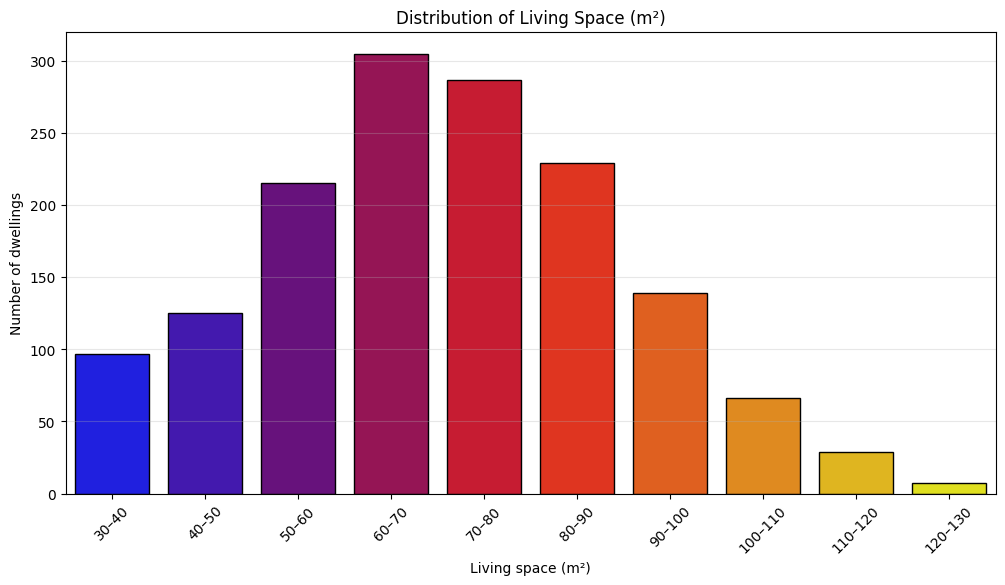

In [2]:
# Barplot über die Verteilung der Wohnungsgrößen in 10-m²-Schritten

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

# 1. Bins definieren
bins = [30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130]
labels = [f"{bins[i]}–{bins[i+1]}" for i in range(len(bins)-1)]

df_result["Woonoppervlakte_bin"] = pd.cut(
    df_result["Woonoppervlakte"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# 2. Häufigkeiten in der richtigen Reihenfolge
counts = df_result["Woonoppervlakte_bin"].value_counts().reindex(labels)

# 3. Farbskala blau → violett → rot
colors = ["#0000FF", "#FF0000", "#FFFF00"]  # blau → violett → rot
cmap = LinearSegmentedColormap.from_list("blue_purple_red", colors, N=10)
palette = [cmap(i) for i in range(10)]

# 4. Plot
plt.figure(figsize=(12, 6))

sns.barplot(
    x=labels,
    y=counts.values,
    palette=palette,
    edgecolor="black"
)

plt.title("Distribution of Living Space (m²)")
plt.xlabel("Living space (m²)")
plt.ylabel("Number of dwellings")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)

plt.show()



C:\Users\sk\AppData\Local\Temp\ipykernel_10704\3035278377.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


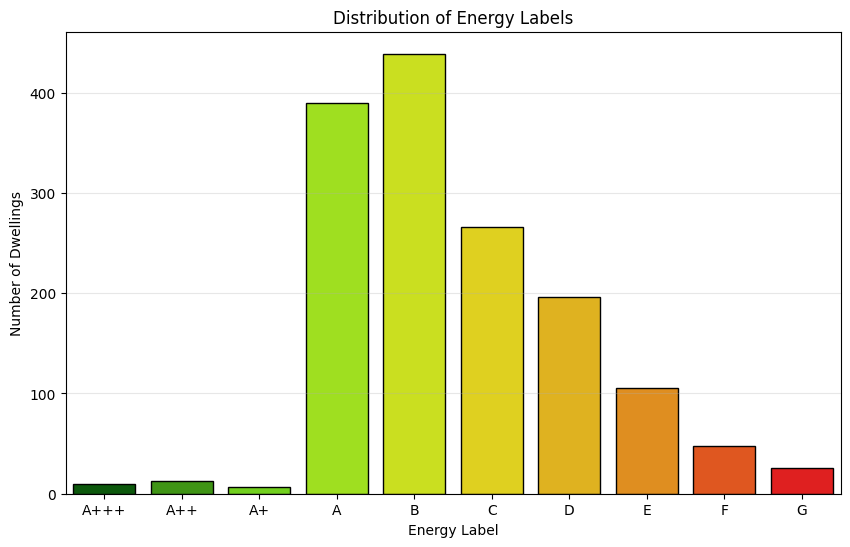

In [3]:
# Histogramm über die Verteilung der Energielabels (A+++ bis G)


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the correct order of energy labels
labels_order = ["A+++", "A++", "A+", "A", "B", "C", "D", "E", "F", "G"]

# Convert to ordered categorical type
df_result["Energielabel"] = pd.Categorical(
    df_result["Energielabel"].astype(str).str.strip().str.upper(),
    categories=labels_order,
    ordered=True
)

plt.figure(figsize=(10, 6))

from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# Farbverlauf definieren
colors = ["#006400", "#7FFF00", "#FFFF00", "#FFA500", "#FF0000"]  
cmap = LinearSegmentedColormap.from_list("custom_gyr", colors, N=10)

# Diskrete Palette extrahieren
palette = [cmap(i) for i in range(cmap.N)]

sns.countplot(
    data=df_result,
    x="Energielabel",
    order=labels_order,
    palette=palette,
    edgecolor="black"
)


plt.title("Distribution of Energy Labels")
plt.xlabel("Energy Label")
plt.ylabel("Number of Dwellings")
plt.grid(axis="y", alpha=0.3)

plt.show()


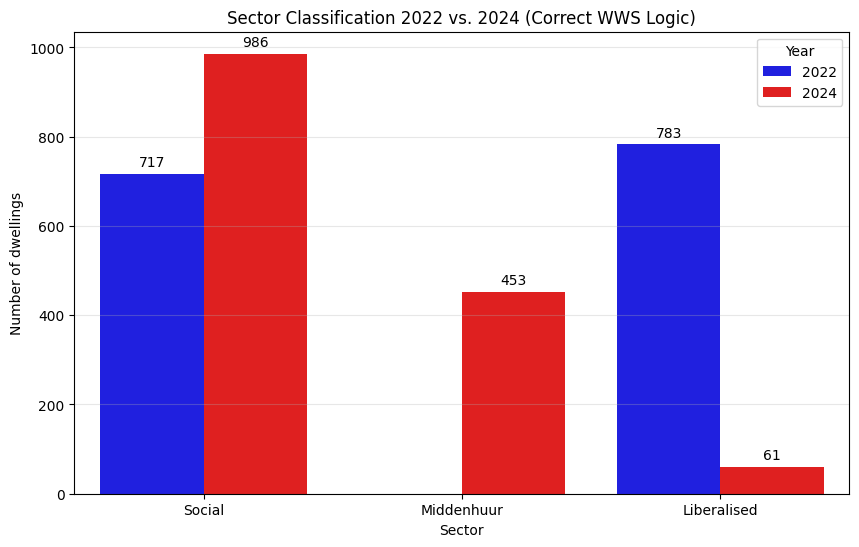

In [4]:
# Balkendiagramm über die Verteilung nach Sektoren ('sociale huursector' / 'middenhuur' / 'vrije sector'

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- SEGMENTGRENZEN ---
LIBERALISATIE_2022 = 763.47   # 2022 liberalisatiegrens
SOCIAL_2024 = 143             # Punkte
MIDDENHUUR_2024 = 186         # Punkte

# --- Klassifikation 2022 (nach Miete) ---
def classify_2022(huur):
    if huur <= LIBERALISATIE_2022:
        return "Social"
    else:
        return "Liberalised"

# --- Klassifikation 2024 (nach Punkten) ---
def classify_2024(points):
    if points <= SOCIAL_2024:
        return "Social"
    elif points <= MIDDENHUUR_2024:
        return "Middenhuur"
    else:
        return "Liberalised"

# --- Anwenden ---
df_result["Sector_2022"] = df_result["Huur_kalt_2022"].apply(classify_2022)
df_result["Sector_2024"] = df_result["WWS_2024"].apply(classify_2024)

# --- Reihenfolge ---
sector_order = ["Social", "Middenhuur", "Liberalised"]

# --- Zählen ---
sector_counts = pd.DataFrame({
    "2022": df_result["Sector_2022"].value_counts().reindex(sector_order),
    "2024": df_result["Sector_2024"].value_counts().reindex(sector_order)
}).reset_index().rename(columns={"index": "Sector"})

# --- Melt für Seaborn ---
sector_melted = sector_counts.melt(
    id_vars="Sector",
    var_name="Year",
    value_name="Count"
)

# --- Plot ---
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=sector_melted,
    x="Sector",
    y="Count",
    hue="Year",
    palette=["blue", "red"]
)

# --- Beschriftung ---
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 3),
            textcoords="offset points"
        )

plt.title("Sector Classification 2022 vs. 2024 (Correct WWS Logic)")
plt.xlabel("Sector")
plt.ylabel("Number of dwellings")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Year")

plt.show()


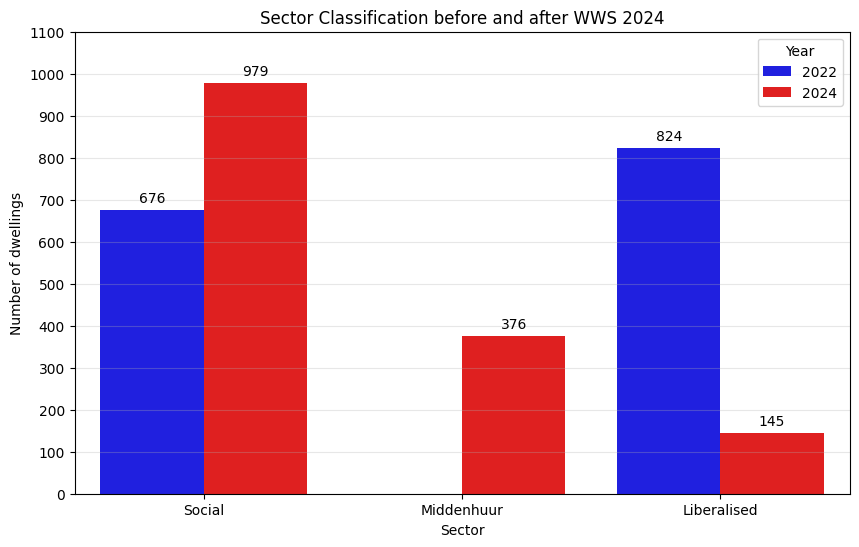

In [5]:
# Balkendiagramm über die Verteilung nach Sektoren ('sociale huursector' / 'middenhuur' / 'vrije sector'

import pandas as pd

# Thresholds
LIBERALISATIE_2022 = 763.47
SOCIAL_2024 = 879.66
MIDDENHUUR_2024 = 1123.13

# Sector classification 2022
def classify_2022(huur):
    if huur <= LIBERALISATIE_2022:
        return "Social"
    else:
        return "Liberalised"

# Sector classification 2024
def classify_2024(huur):
    if huur <= SOCIAL_2024:
        return "Social"
    elif huur <= MIDDENHUUR_2024:
        return "Middenhuur"
    else:
        return "Liberalised"

# Apply classification
df_result["Sector_2022"] = df_result["Huur_kalt_2023"].apply(classify_2022)
df_result["Sector_2024"] = df_result["Huur_kalt_2023"].apply(classify_2024)


import matplotlib.pyplot as plt
import seaborn as sns

sector_order = ["Social", "Middenhuur", "Liberalised"]

# Count sectors
sector_counts = pd.DataFrame({
    "2022": df_result["Sector_2022"].value_counts().reindex(sector_order),
    "2024": df_result["Sector_2024"].value_counts().reindex(sector_order)
})

sector_counts = sector_counts.reset_index().rename(columns={"index": "Sector"})

# Melt for seaborn
sector_melted = sector_counts.melt(id_vars="Sector", var_name="Year", value_name="Count")

plt.figure(figsize=(10, 6))

# WICHTIG: Achse speichern
ax = sns.barplot(
    data=sector_melted,
    x="Sector",
    y="Count",
    hue="Year",
    palette=["blue", "red"]
)

# Zahlen über die Balken schreiben
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Nur echte Balken beschriften
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 3),
            textcoords="offset points"
        )

plt.title("Sector Classification before and after WWS 2024")
plt.xlabel("Sector")
plt.ylabel("Number of dwellings")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Year")
plt.gca().set_yticks(range(0, df_result["Sector_2022"].count() + 100, 100))
plt.ylim(0, 1100)

plt.show()



C:\Users\sk\AppData\Local\Temp\ipykernel_10704\2789490744.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


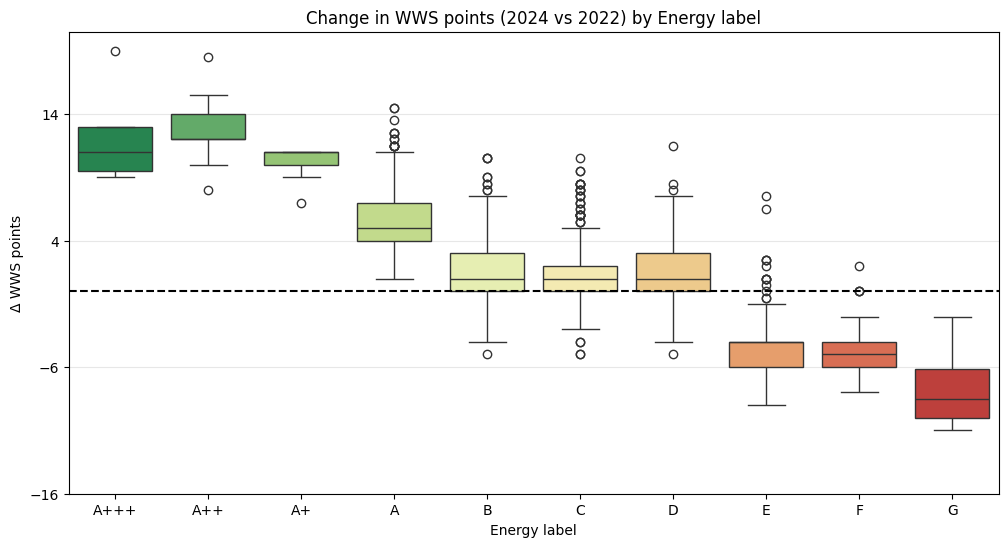

In [6]:
# Boxplot zur Veränderung des Energielabel von WWS 2022 nach WWS 2024

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define correct label order
labels_order = ["A+++", "A++", "A+", "A", "B", "C", "D", "E", "F", "G"]

# Ensure Energielabel is ordered categorical
df_result["Energielabel"] = pd.Categorical(
    df_result["Energielabel"].astype(str).str.strip().str.upper(),
    categories=labels_order,
    ordered=True
)

df_result["WWS_diff"] = df_result["WWS_2024"] - df_result["WWS_2022"]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_result,
    x="Energielabel",
    y="WWS_diff",
    order=labels_order,
    palette = sns.color_palette("RdYlGn_r", 10)
)

plt.axhline(0, color="black", linestyle="--")
plt.title("Change in WWS points (2024 vs 2022) by Energy label")
plt.xlabel("Energy label")
plt.ylabel("Δ WWS points")

# Y-axis in 10-point steps (optional)
plt.gca().set_yticks(range(int(df_result["WWS_diff"].min()) - 5,
                           int(df_result["WWS_diff"].max()) + 5, 10))

plt.grid(axis="y", alpha=0.3)
plt.show()


C:\Users\sk\AppData\Local\Temp\ipykernel_10704\933748062.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_result.pivot_table(


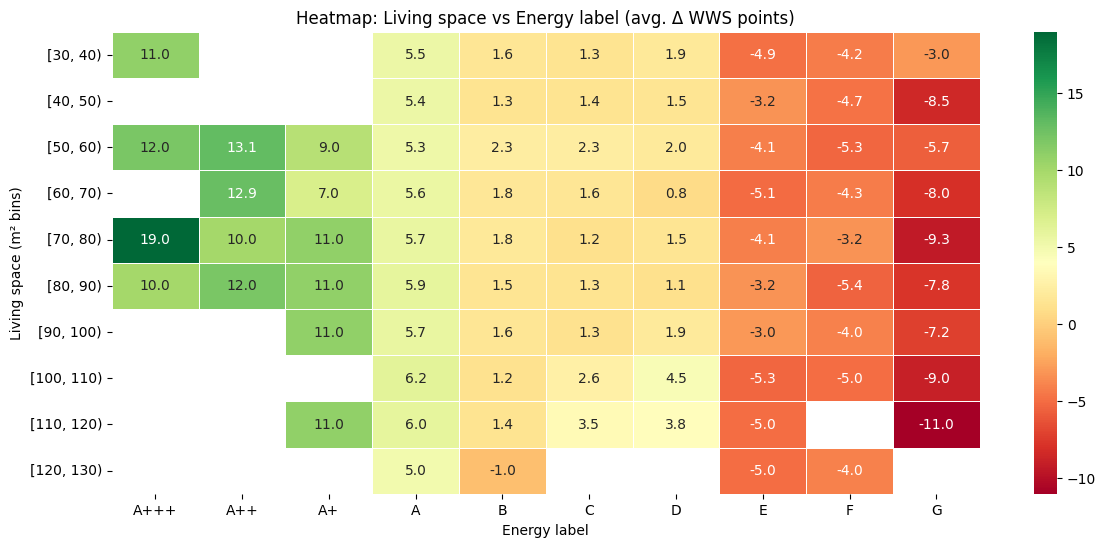

In [7]:
# Heatmap die die Korrelation zwischen Energielabel und Wohnfläche aufdeckt

import numpy as np

# Create 10 m² bins
df_result["LivingSpaceBin"] = pd.cut(
    df_result["Woonoppervlakte"],
    bins=range(20, 140, 10),
    right=False,
    include_lowest=True
)

# Pivot table: average WWS_diff or average potential
pivot = df_result.pivot_table(
    index="LivingSpaceBin",
    columns="Energielabel",
    values="WWS_diff",   # or "Huurpotentieel_2024"
    aggfunc="mean"
).reindex(columns=labels_order)

plt.figure(figsize=(14, 6))

sns.heatmap(
    pivot,
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt=".1f"
)

plt.title("Heatmap: Living space vs Energy label (avg. Δ WWS points)")
plt.xlabel("Energy label")
plt.ylabel("Living space (m² bins)")

plt.show()


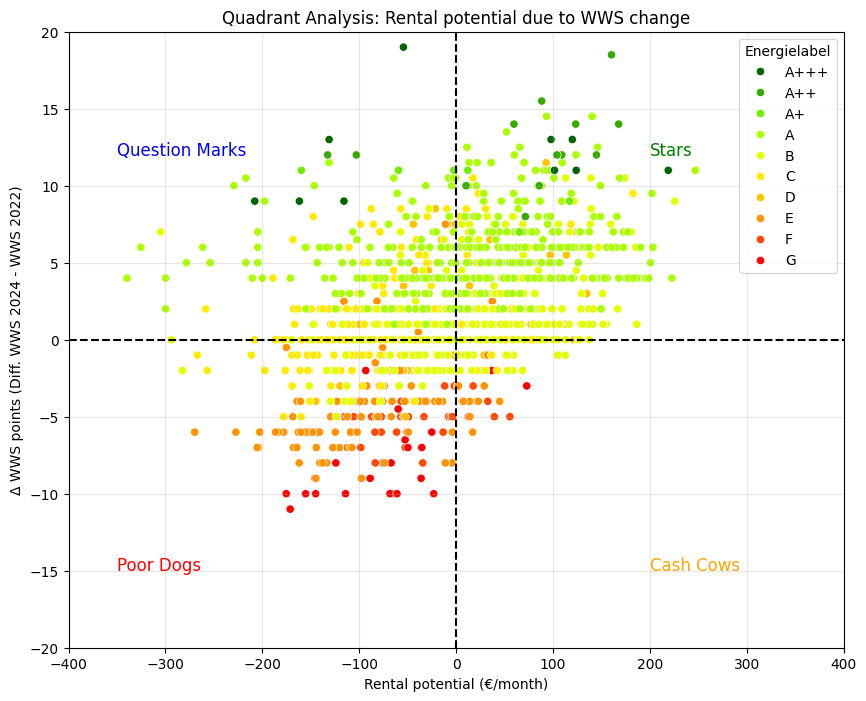

In [8]:
# Quadrantenanalyse

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Eigene lineare Grün-Gelb-Rot-Skala
colors = ["#006400", "#7FFF00", "#FFFF00", "#FFA500", "#FF0000"]  # dunkelgrün → hellgrün → gelb → orange → rot
cmap = LinearSegmentedColormap.from_list("custom_gyr", colors, N=10)

# Palette für Seaborn extrahieren
palette = [cmap(i) for i in range(cmap.N)]

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_result,
    x="Huurpotentieel_2024",
    y="WWS_diff",
    hue="Energielabel",
    palette = palette
    )

# Add quadrant lines
plt.axvline(0, color="black", linestyle="--")
plt.axhline(0, color="black", linestyle="--")

plt.title("Quadrant Analysis: Rental potential due to WWS change")
plt.xlabel("Rental potential (€/month)")
plt.ylabel("Δ WWS points (Diff. WWS 2024 - WWS 2022)")
plt.xlim(-400, 400)
plt.ylim(-20, 20)

plt.text(200, 12, "Stars", fontsize=12, color="green")
plt.text(-350, 12, "Question Marks", fontsize=12, color="blue")
plt.text(-350, -15, "Poor Dogs", fontsize=12, color="red")
plt.text(200, -15, "Cash Cows", fontsize=12, color="orange")

plt.grid(alpha=0.3)
plt.show()


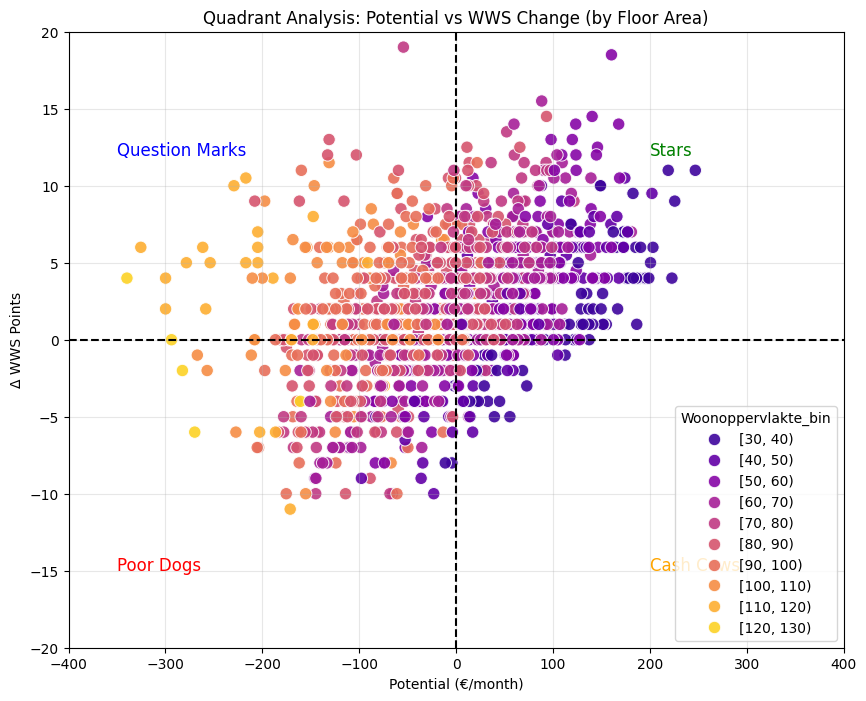

In [9]:
# Quadrantenanalyse

df_result["Woonoppervlakte_bin"] = pd.cut(
    df_result["Woonoppervlakte"],
    bins=range(30, 131, 10),   # 20–150 m² in 10er Schritten
    right=False,
    include_lowest=True
)

palette = sns.color_palette("magma", 10)


import matplotlib.pyplot as plt
import seaborn as sns

# Create bins
df_result["Woonoppervlakte_bin"] = pd.cut(
    df_result["Woonoppervlakte"],
    bins=range(30, 131, 10),
    right=False,
    include_lowest=True
)

# Strong palette for 10 bins
palette = sns.color_palette("plasma", 10)

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_result,
    x="Huurpotentieel_2024",
    y="WWS_diff",
    hue="Woonoppervlakte_bin",
    palette=palette,
    s=80,
    alpha=0.9
)

# Quadrant lines
plt.axvline(0, color="black", linestyle="--")
plt.axhline(0, color="black", linestyle="--")

# Titles and labels
plt.title("Quadrant Analysis: Potential vs WWS Change (by Floor Area)")
plt.xlabel("Potential (€/month)")
plt.ylabel("Δ WWS Points")

# Axis limits
plt.xlim(-400, 400)
plt.ylim(-20, 20)

# Tick steps
plt.xticks(range(-400, 401, 100))
plt.yticks(range(-20, 21, 5))

# BCG labels
plt.text(200, 12, "Stars", fontsize=12, color="green")
plt.text(-350, 12, "Question Marks", fontsize=12, color="blue")
plt.text(-350, -15, "Poor Dogs", fontsize=12, color="red")
plt.text(200, -15, "Cash Cows", fontsize=12, color="orange")

plt.grid(alpha=0.3)
plt.show()




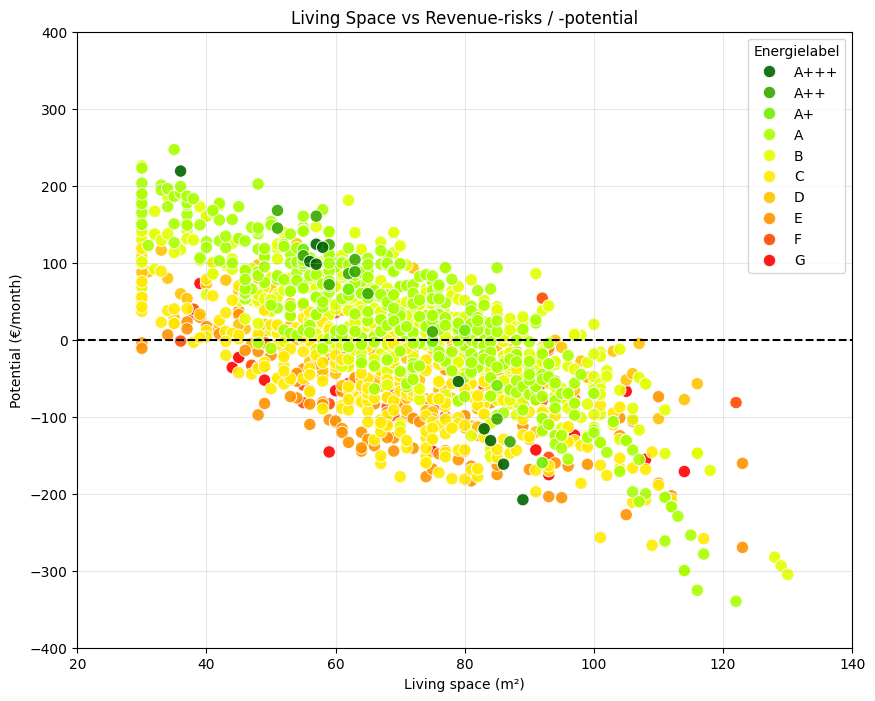

In [10]:
# Analyse Wohnungsgröße in Abhängigkeit zu Gewinnen und Verlusten auf Grundlage des WWS 2024

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Eigene lineare Grün-Gelb-Rot-Skala
colors = ["#006400", "#7FFF00", "#FFFF00", "#FFA500", "#FF0000"]  # dunkelgrün → hellgrün → gelb → orange → rot
cmap = LinearSegmentedColormap.from_list("custom_gyr", colors, N=10)

# Palette für Seaborn extrahieren
palette = [cmap(i) for i in range(cmap.N)]

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_result,
    x="Woonoppervlakte",
    y="Huurpotentieel_2024",
    hue="Energielabel",
    palette=palette,
    s=80,
    alpha=0.9
)

# Add lines
#plt.axvline(0, color="black", linestyle="--")
plt.axhline(0, color="black", linestyle="--")

plt.title("Living Space vs Revenue-risks / -potential")
plt.xlabel("Living space (m²)")
plt.ylabel("Potential (€/month)")
plt.xlim(20, 140)
plt.ylim(-400, 400)

plt.grid(alpha=0.3)
plt.show()
